In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
new_metrics = pd.read_csv("new_metrics.csv")
old_metrics = pd.read_csv("old_metrics.csv")

In [3]:
new_metrics["cap"].unique()
new_metrics.rename(columns={"mean": "new_mean", "std": "new_std"}, inplace=True)

In [4]:
old_metrics["cap"].unique()
old_metrics.rename(columns={"mean": "old_mean", "std": "old_std"}, inplace=True)

In [5]:
merged_metrics = pd.merge(new_metrics, old_metrics, on=["cap", "pretrain_data", "train_data"], suffixes=('_new', '_old'))
merged_metrics

,pretrain_data,cap,train_data,new_mean,new_std,old_mean,old_std
0,both,1.0,f3,0.560413,0.044078,0.496917,0.038309
1,both,1.0,f3_N,0.571537,0.048778,0.539408,0.050019
2,both,1.0,seam_ai,0.548696,0.041296,0.557271,0.044453
3,both,1.0,seam_ai_N,0.551591,0.046353,0.554024,0.040972
4,both,10.0,f3,0.643562,0.020244,0.682201,0.023440
...,...,...,...,...,...,...,...
103,sup,10.0,seam_ai_N,0.652002,0.017600,0.688946,0.017851
104,sup,100.0,f3,0.701854,0.014283,0.706747,0.013517
105,sup,100.0,f3_N,0.715877,0.009749,0.710030,0.015664
106,sup,100.0,seam_ai,0.687323,0.009741,0.719911,0.014827


In [6]:
merged_metrics['pretrain_data'].unique()

array(['both', 'both_N', 'coco', 'f3', 'f3_N', 'imagenet', 'seam_ai',
       'seam_ai_N', 'sup'], dtype=object)

In [7]:
def plot_metrics_for_train_data(train_data_filter, cap_filter, save_path=None):
    # Filter the data for the given train_data and cap
    filtered_data = merged_metrics[(merged_metrics['train_data'] == train_data_filter) & 
                                    (merged_metrics['cap'] == cap_filter)]

    # Plot the data
    if not filtered_data.empty:
        labels = filtered_data['pretrain_data'].values
        old_means = filtered_data['old_mean'].values
        new_means = filtered_data['new_mean'].values
        old_stds = filtered_data['old_std'].values
        new_stds = filtered_data['new_std'].values

        x = np.arange(len(labels))  # the label locations
        width = 0.35  # the width of the bars

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.bar(x - width/2, old_means, width, yerr=old_stds, capsize=5, label='Old Metrics', color='blue')
        ax.bar(x + width/2, new_means, width, yerr=new_stds, capsize=5, label='New Metrics', color='orange')

        # Add labels and title
        ax.set_ylabel('Mean')
        ax.set_title(f'Metrics for train_data={train_data_filter} and cap={cap_filter}')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.legend()

        plt.tight_layout()

        # Save the plot if save_path is provided
        if save_path:
            plt.savefig(save_path, )
            print(f"Plot saved to {save_path}")

        plt.show()
    else:
        print(f"No data available for train_data={train_data_filter} and cap={cap_filter}")

In [8]:
merged_metrics['cap'].unique()

array([  1.,  10., 100.])

Plot saved to outputs/f3&1.0.png


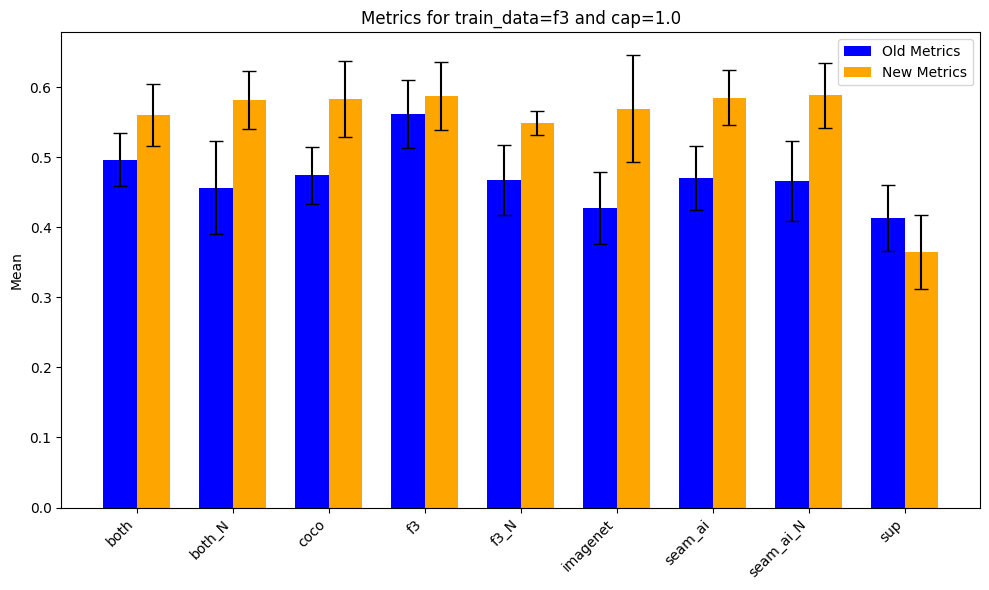

Plot saved to outputs/f3_N&1.0.png


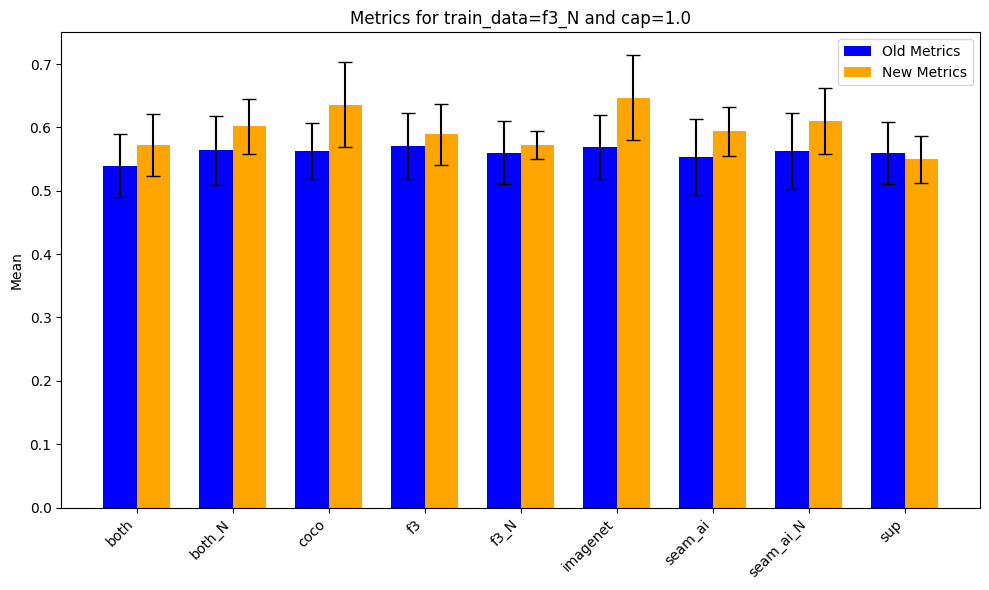

Plot saved to outputs/seam_ai&1.0.png


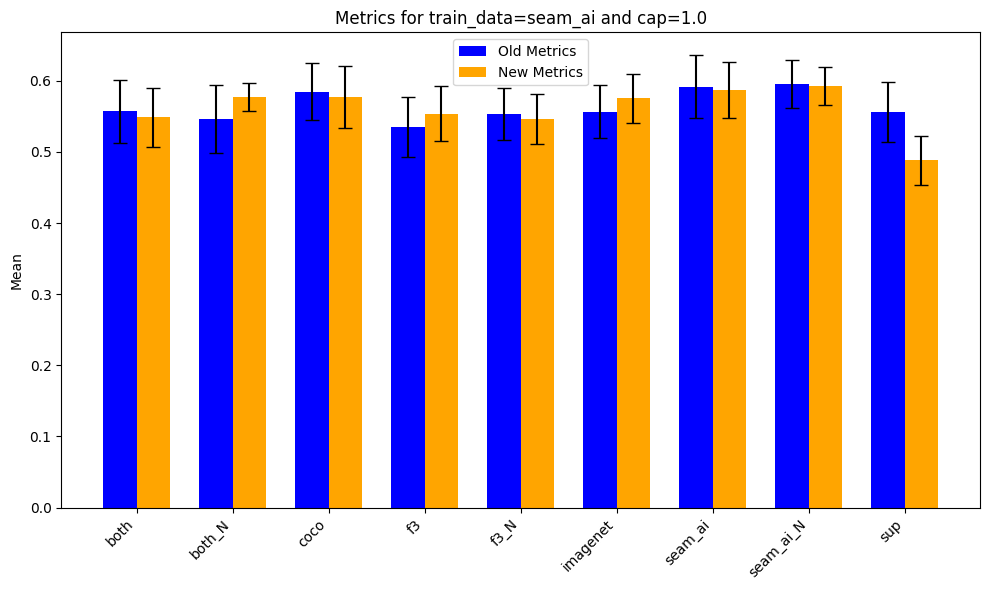

Plot saved to outputs/seam_ai_N&1.0.png


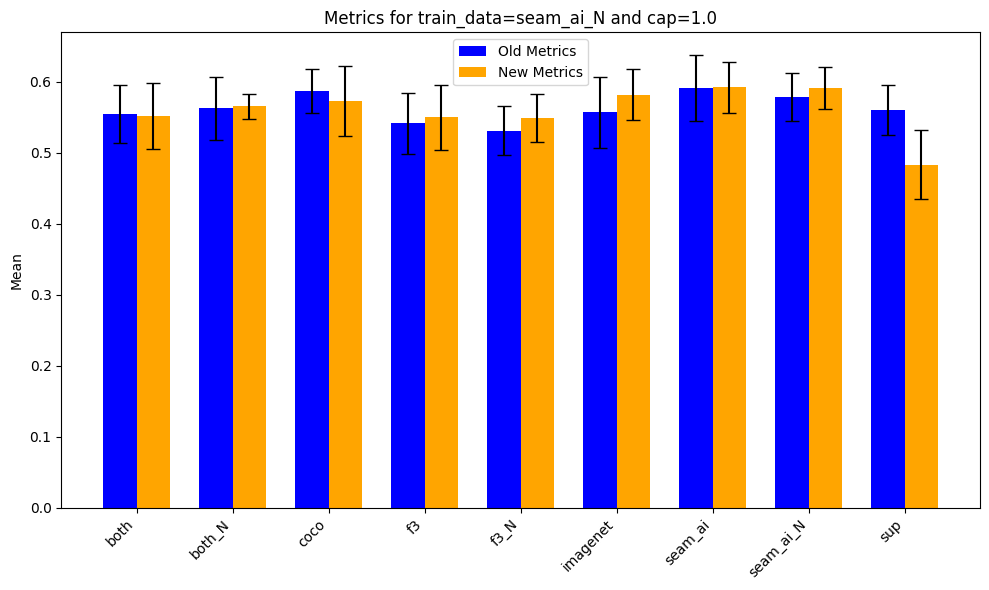

Plot saved to outputs/f3&10.0.png


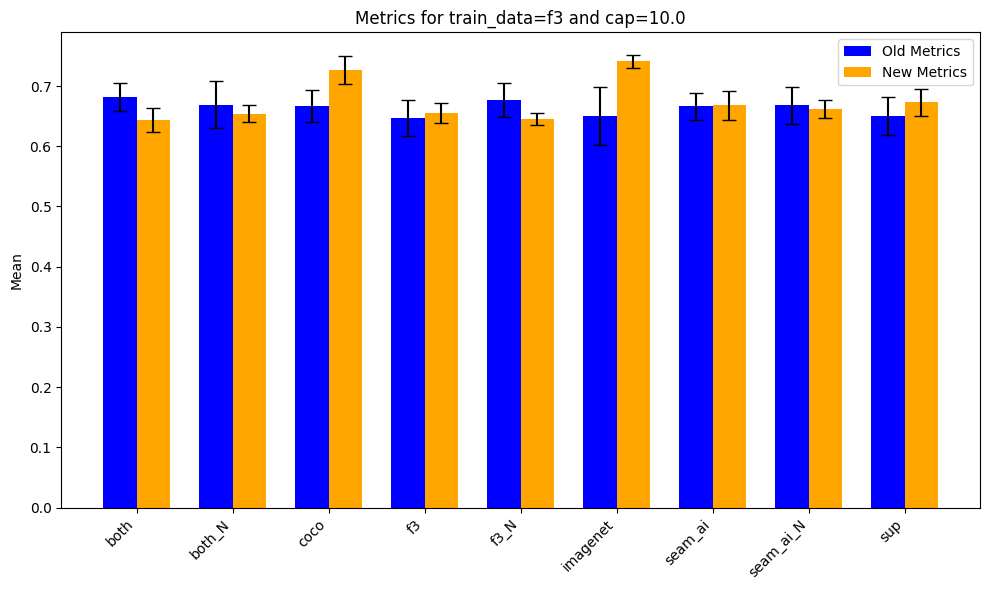

Plot saved to outputs/f3_N&10.0.png


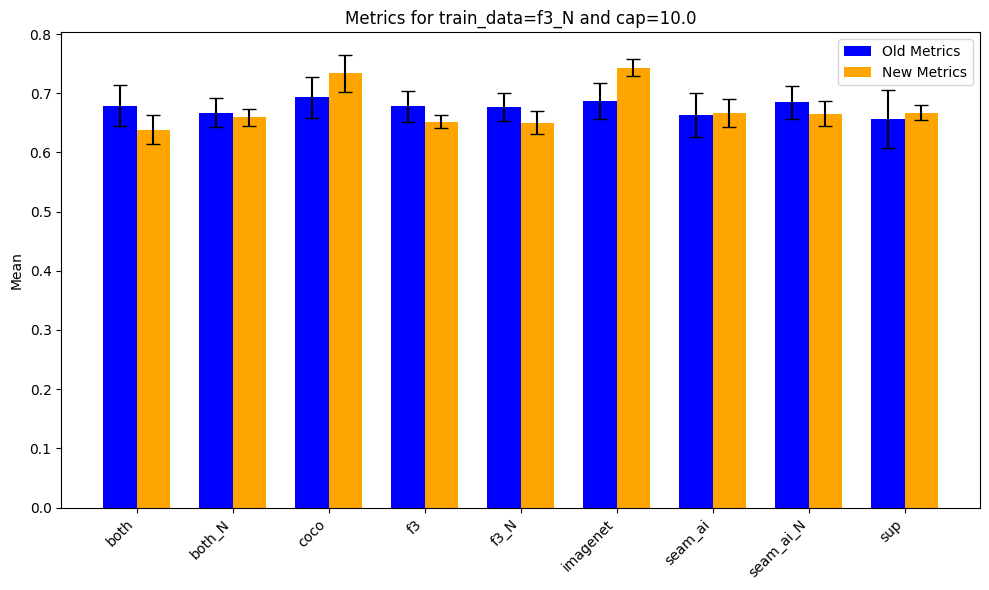

Plot saved to outputs/seam_ai&10.0.png


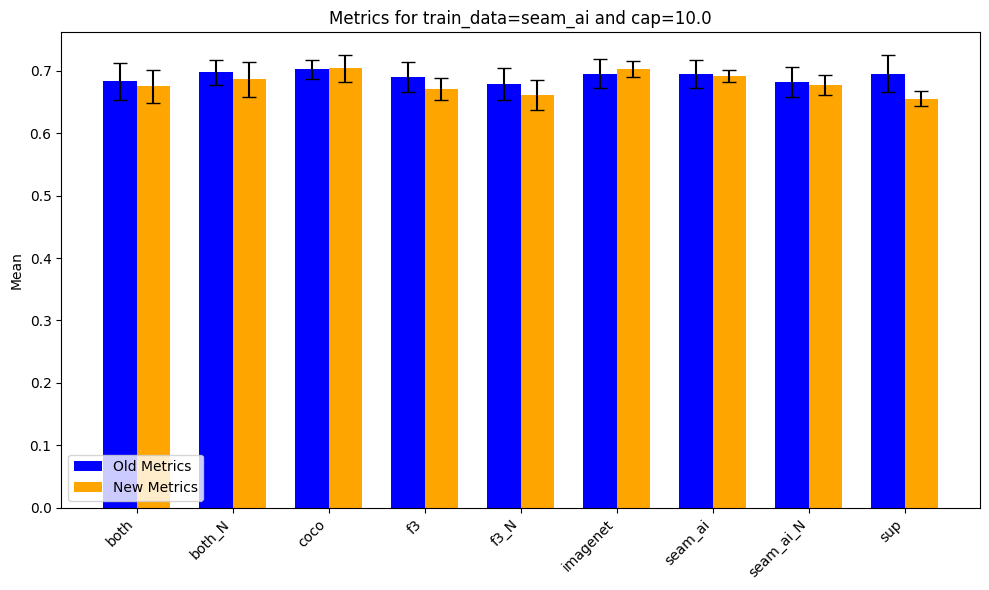

Plot saved to outputs/seam_ai_N&10.0.png


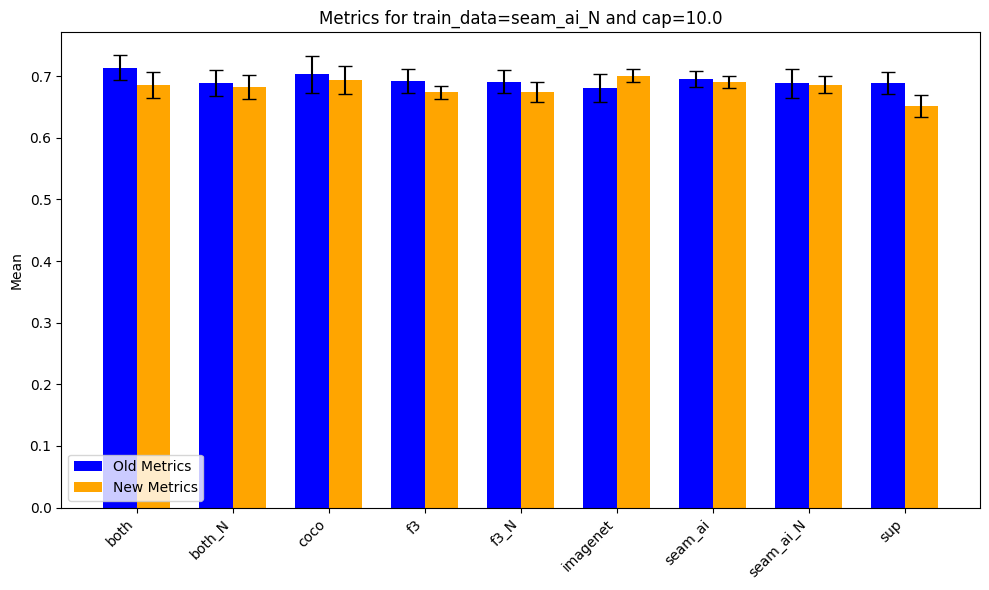

Plot saved to outputs/f3&100.0.png


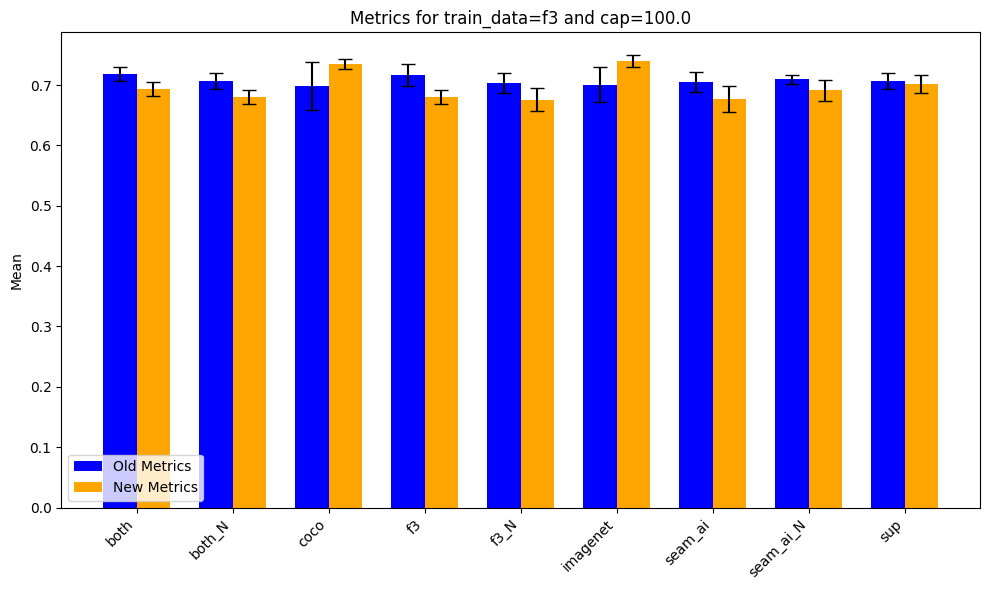

Plot saved to outputs/f3_N&100.0.png


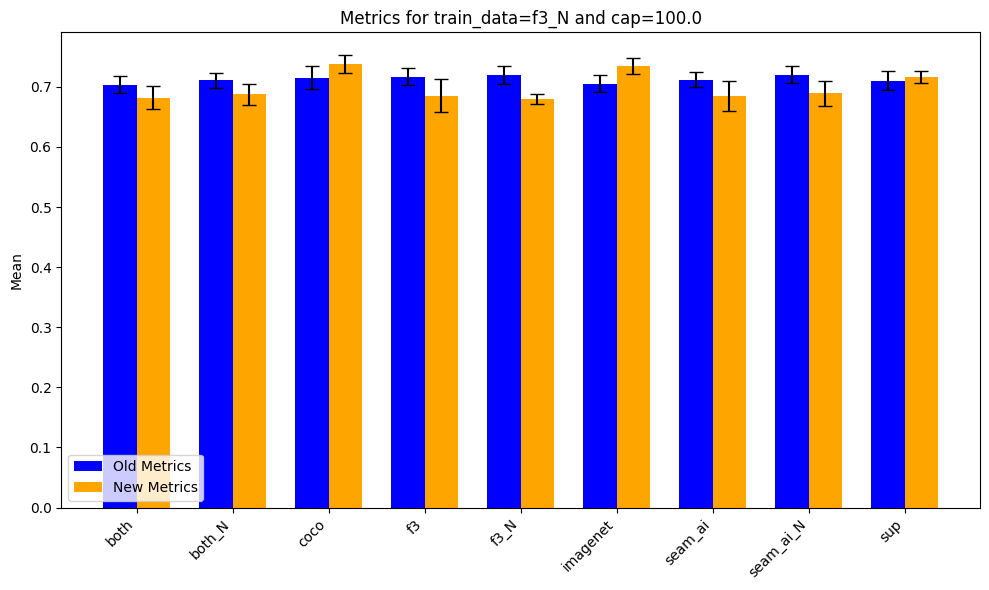

Plot saved to outputs/seam_ai&100.0.png


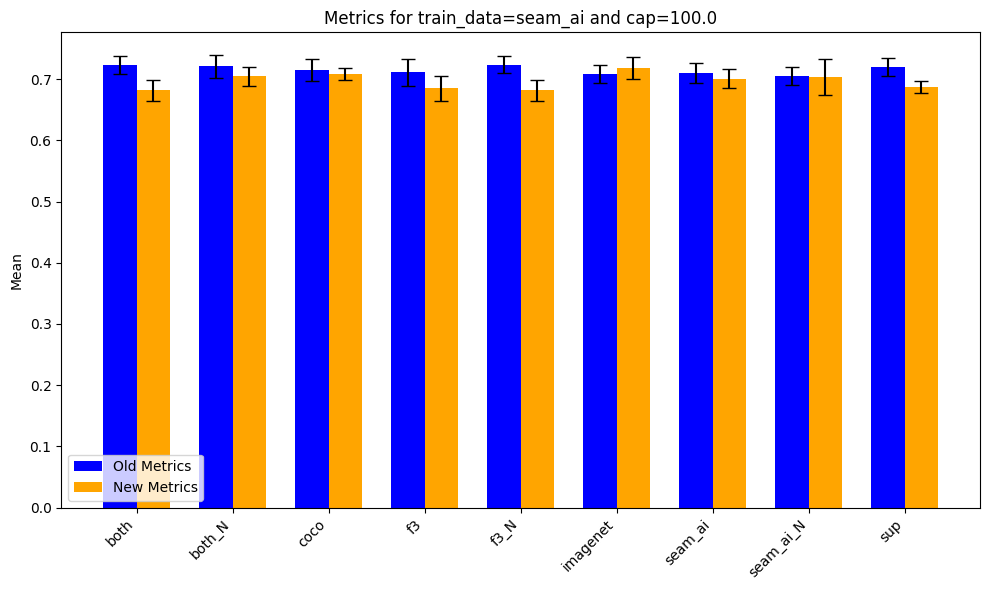

Plot saved to outputs/seam_ai_N&100.0.png


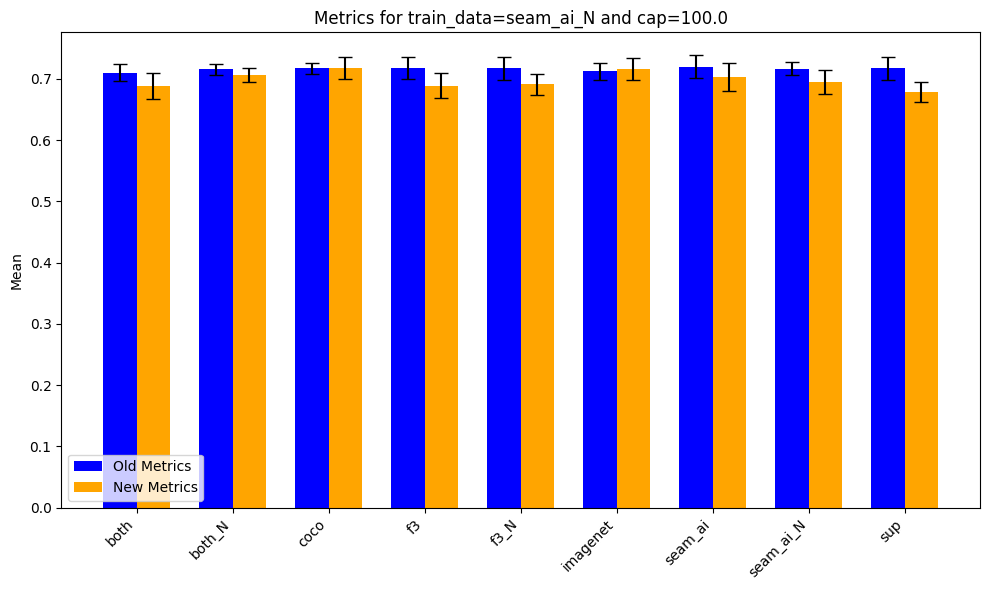

In [9]:
# Call the function for every unique train_data in merged_metrics
for cap_filter in merged_metrics['cap'].unique():      
    for train_data in merged_metrics['train_data'].unique():
        save_path = f'outputs/{train_data}&{cap_filter}.png'
        plot_metrics_for_train_data(train_data, cap_filter, save_path=save_path)


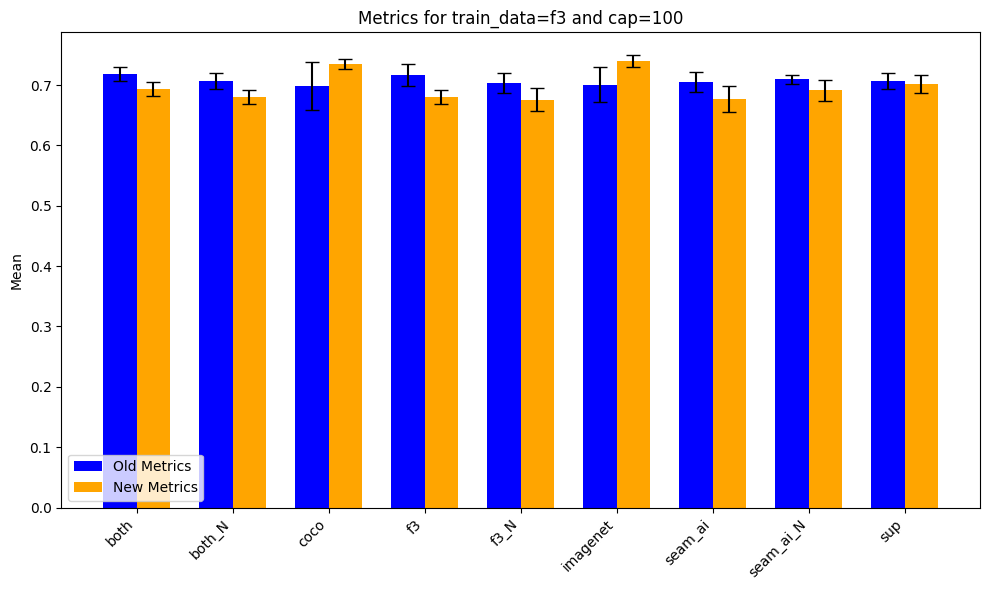

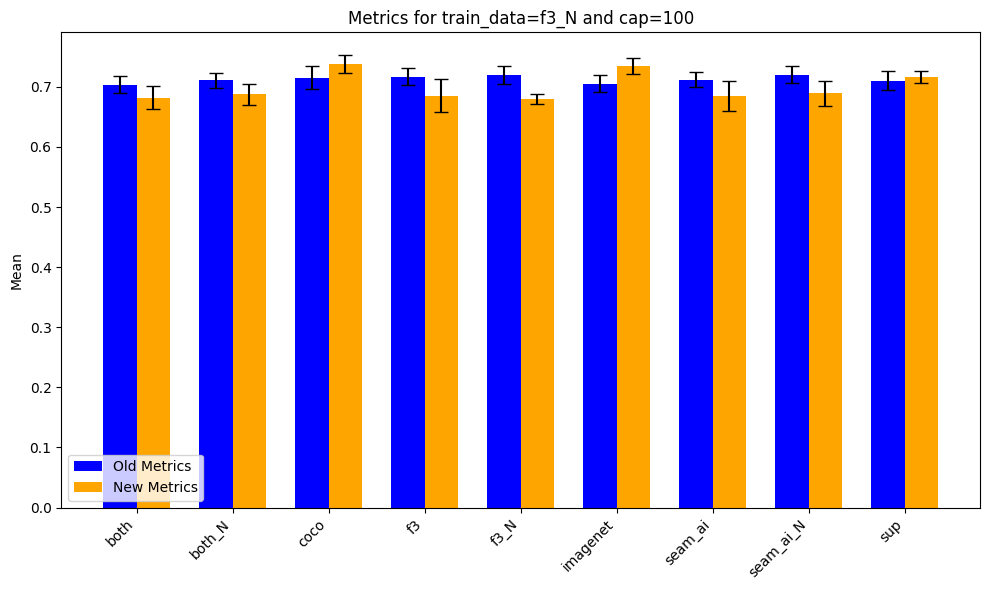

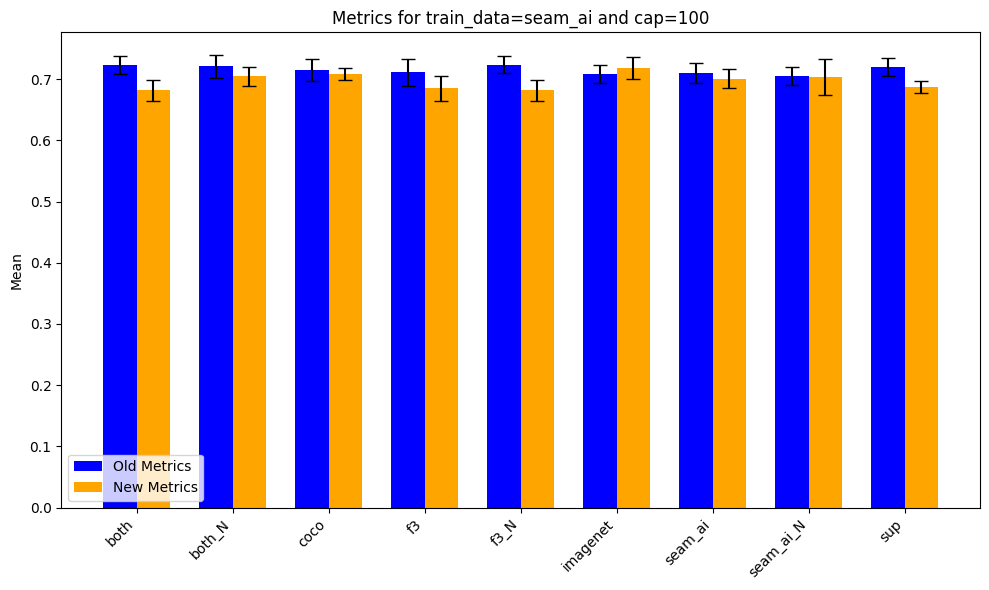

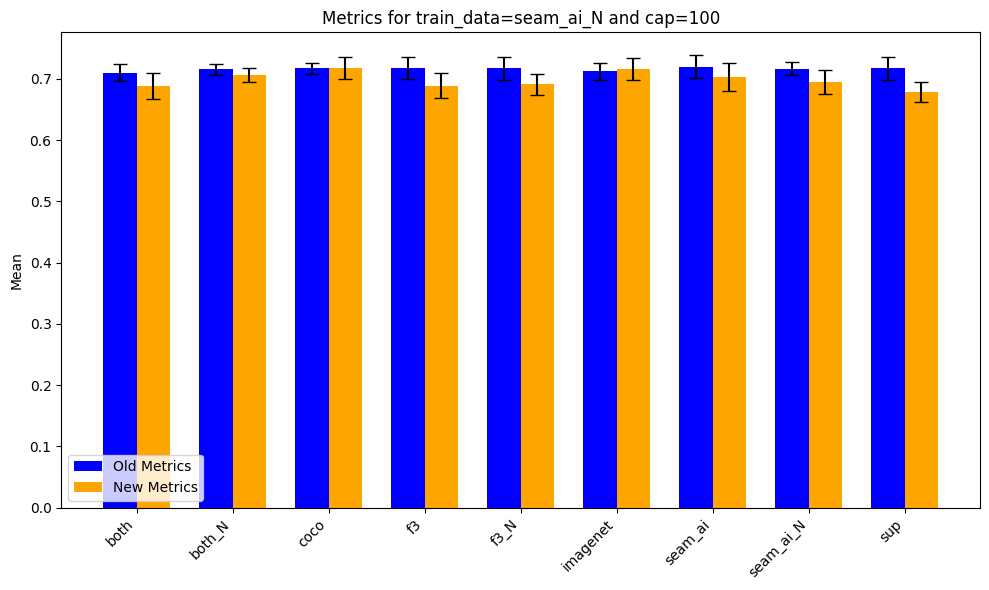

In [10]:
# Call the function for every unique train_data in merged_metrics
for train_data in merged_metrics['train_data'].unique():
    cap_filter = 100
    plot_metrics_for_train_data(train_data, cap_filter)
